In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
matches = pd.read_csv("/content/sample_data/matches (1).csv")
deliveries = pd.read_csv("/content/sample_data/deliveries.csv")

matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [ ]:
matches.info()
matches.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

,id,season,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,2013.444444,0.025132,13.283069,3.350529
std,3464.478148,3.366895,0.156630,23.471144,3.387963
min,1.000000,2008.000000,0.000000,0.000000,0.000000
25%,189.750000,2011.000000,0.000000,0.000000,0.000000
50%,378.500000,2013.000000,0.000000,0.000000,4.000000
75%,567.250000,2016.000000,0.000000,19.000000,6.000000
max,11415.000000,2019.000000,1.000000,146.000000,10.000000


In [ ]:
#i) Match won by the maximum margin of runs.

max_runs = matches[matches['win_by_runs'] == matches['win_by_runs'].max()]
max_runs[['season','team1','team2','winner','win_by_runs']]


,season,team1,team2,winner,win_by_runs
43,2017,Mumbai Indians,Delhi Daredevils,Mumbai Indians,146


In [ ]:
#ii) Match won by maximum wickets.

max_wickets = matches[matches['win_by_wickets'] == matches['win_by_wickets'].max()]
max_wickets[['season','team1','team2','winner','win_by_wickets']]#This match shows the strongest chasing performance.

,season,team1,team2,winner,win_by_wickets
2,2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,10
34,2017,Delhi Daredevils,Kings XI Punjab,Kings XI Punjab,10
71,2008,Mumbai Indians,Deccan Chargers,Deccan Chargers,10
119,2009,Kings XI Punjab,Delhi Daredevils,Delhi Daredevils,10
183,2010,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,10
298,2011,Mumbai Indians,Rajasthan Royals,Rajasthan Royals,10
376,2012,Rajasthan Royals,Mumbai Indians,Mumbai Indians,10
390,2013,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,10
542,2015,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,10
590,2016,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,10


In [ ]:
#iii) Match won by the minimum margin of runs.

min_runs = matches[(matches['win_by_runs'] > 0)]
min_runs = min_runs[min_runs['win_by_runs'] == min_runs['win_by_runs'].min()]
min_runs[['season','team1','team2','winner','win_by_runs']]

,season,team1,team2,winner,win_by_runs
58,2017,Mumbai Indians,Rising Pune Supergiant,Mumbai Indians,1
105,2008,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,1
163,2009,Kings XI Punjab,Deccan Chargers,Kings XI Punjab,1
344,2012,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,1
350,2012,Mumbai Indians,Pune Warriors,Mumbai Indians,1
518,2015,Chennai Super Kings,Delhi Daredevils,Chennai Super Kings,1
598,2016,Gujarat Lions,Delhi Daredevils,Gujarat Lions,1
614,2016,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,1
734,2019,Royal Challengers Bangalore,Chennai Super Kings,Royal Challengers Bangalore,1
755,2019,Mumbai Indians,Chennai Super Kings,Mumbai Indians,1


In [ ]:
#iv) Match won by minimum wickets.

min_wickets = matches[(matches['win_by_wickets'] > 0)]
min_wickets = min_wickets[min_wickets['win_by_wickets'] == min_wickets['win_by_wickets'].min()]
min_wickets[['season','team1','team2','winner','win_by_wickets']]

,season,team1,team2,winner,win_by_wickets
559,2015,Kings XI Punjab,Kolkata Knight Riders,Kolkata Knight Riders,1
636,2018,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,1
642,2018,Mumbai Indians,Sunrisers Hyderabad,Sunrisers Hyderabad,1


In [ ]:
#v)Matches where D/L method was and wasn't applied.
matches['dl_applied'].value_counts()

,count
dl_applied,
0,737
1,19


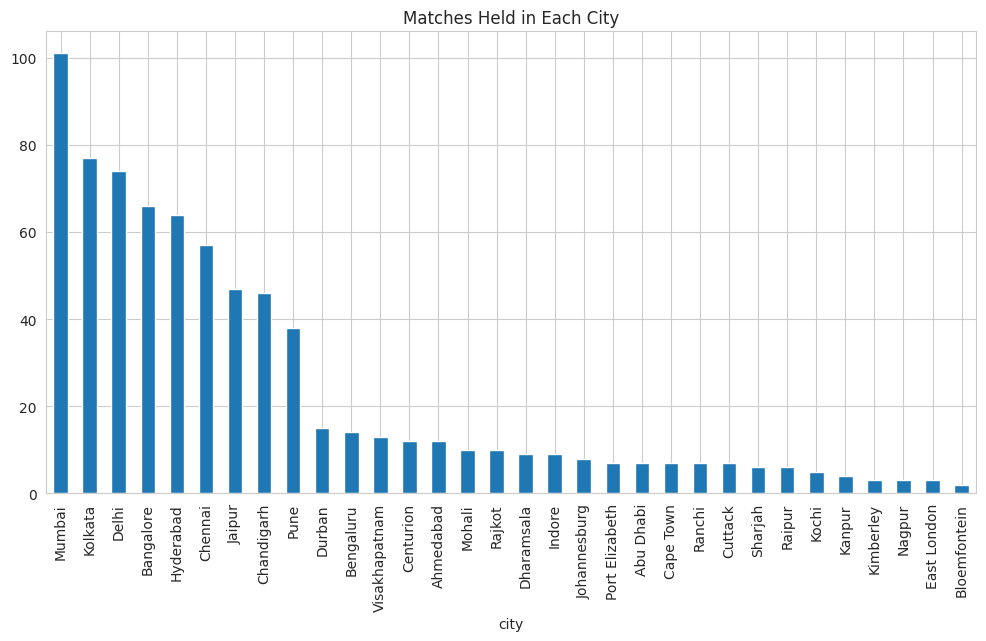

In [ ]:
#vi) No. of matches held in each city.
city_matches = matches['city'].value_counts()
plt.figure(figsize=(12,6))
city_matches.plot(kind='bar')
plt.title("Matches Held in Each City")
plt.show()

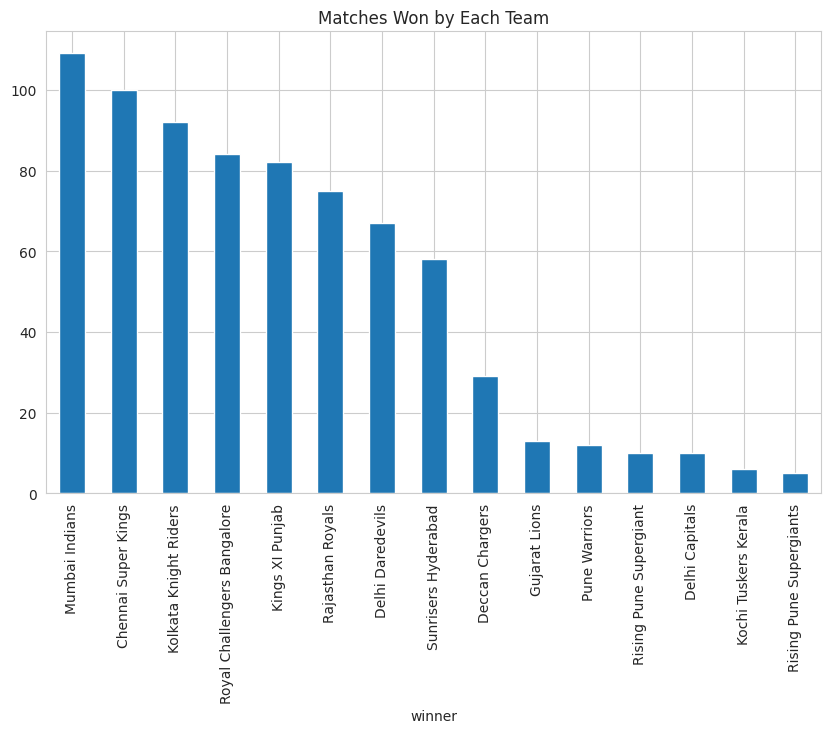

In [ ]:
#vii)No. of matches won by each team.
team_wins = matches['winner'].value_counts()
plt.figure(figsize=(10,6))
team_wins.plot(kind='bar')
plt.title("Matches Won by Each Team")
plt.show()

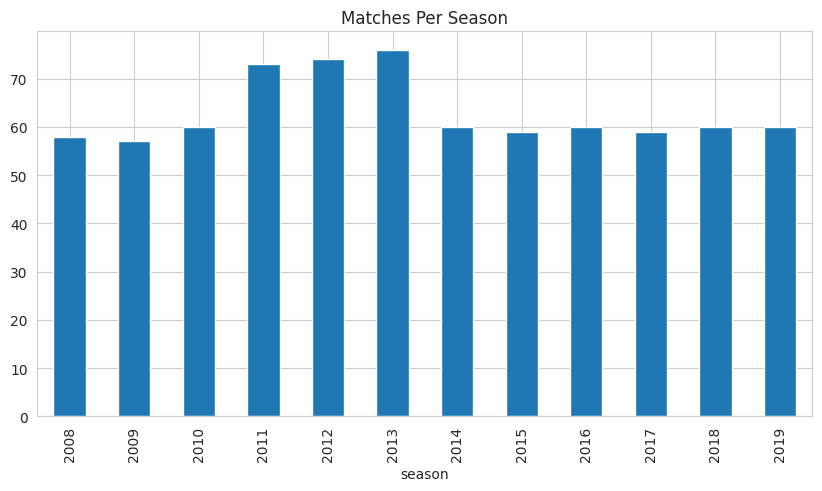

In [ ]:
#viii) No. of matches held every season.
season_matches = matches['season'].value_counts().sort_index()
plt.figure(figsize=(10,5))
season_matches.plot(kind='bar')
plt.title("Matches Per Season")
plt.show()

In [ ]:
#x) Does winning the toss mean winning the match?
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']
matches['toss_win_match_win'].value_counts(normalize=True) * 100

,proportion
toss_win_match_win,
True,51.984127
False,48.015873


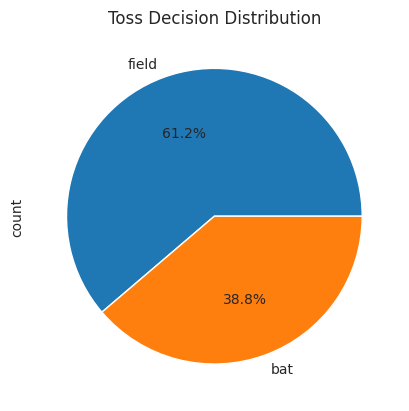

In [ ]:
matches['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Toss Decision Distribution")
plt.show()

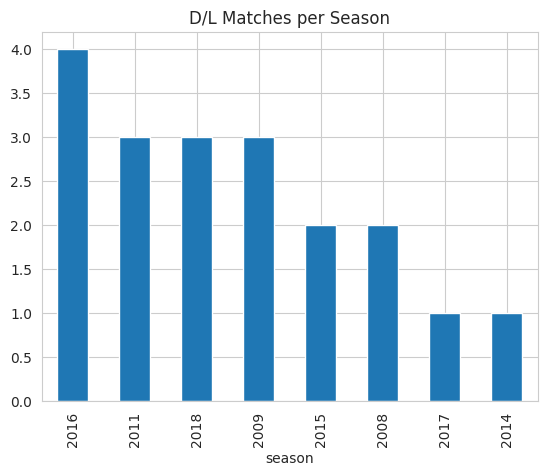

In [ ]:
dl_season = matches[matches['dl_applied']==1]['season'].value_counts()
dl_season.plot(kind='bar')
plt.title("D/L Matches per Season")
plt.show()

In [ ]:
matches['result'].value_counts()

,count
result,
normal,743
tie,9
no result,4


In [ ]:
matches['toss_winner'].value_counts().head(10)

,count
toss_winner,
Mumbai Indians,98
Kolkata Knight Riders,92
Chennai Super Kings,89
Kings XI Punjab,81
Royal Challengers Bangalore,81
Delhi Daredevils,80
Rajasthan Royals,80
Sunrisers Hyderabad,46
Deccan Chargers,43


In [ ]:
defend = matches[matches['win_by_runs'] > 0]['venue'].value_counts()
chase = matches[matches['win_by_wickets'] > 0]['venue'].value_counts()
print("Best Defending Venue:")
print(defend.head())
print("\nBest Chasing Venue:")
print(chase.head())

Best Defending Venue:
venue
Wankhede Stadium                   35
Feroz Shah Kotla                   33
Eden Gardens                       32
M Chinnaswamy Stadium              30
MA Chidambaram Stadium, Chepauk    30
Name: count, dtype: int64

Best Chasing Venue:
venue
Eden Gardens                                 45
M Chinnaswamy Stadium                        40
Wankhede Stadium                             37
Feroz Shah Kotla                             33
Rajiv Gandhi International Stadium, Uppal    32
Name: count, dtype: int64
